## Modelo de crescimento endógeno - Modelo de inovação horizontal - Romer 

Os códigos abaixo servem para simular o Modelo de Inovação Horizontal (ou "product variety model") de Romer (1990). Eles foram desenvolvidos para contemplar os efeitos de choques e mudanças de políticas sobre o modelo. Este material é complementar aos slides da aula e à lista de exercícios.
  
Sugestão para melhor aprendizado é rodar o modelo base, alterar os parâmetros e buscar construir derivações. O código base é o ponto de partida para construir extensões, gráficos e ampla gama aplicações e análises.

In [1]:
# pacotes - instalação

# NumPy (Cálculo Numérico)
!pip install numpy

# Matplotlib (Gráficos)
!pip install matplotlib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


Exercício 1 - Equilíbrio subótimo, políticas e choques  
  
A partir do código base, explore:  
1) Subsídio ao P&D  
2) Mudança da alocação de capital humano entre setor de bens finais e de pesquisa  
3) Diferenças entre o equilíbrio sub ótimo de Pareto e o socialmente desejável  
4) Maior eficiência do capital humano em produzir conhecimento  
5) Maior taxa de preferência intertemporal  


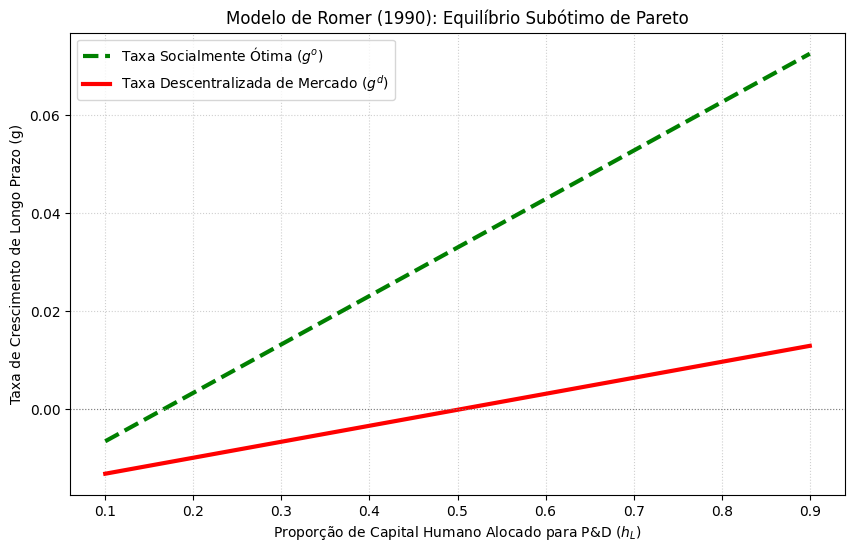

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------
# 1. Definição dos Parâmetros do Modelo de Romer (1990)
# (Para simplificação, usamos a versão de Jones (1995) ou a de Aghion & Howitt (2009)
# que converge para uma taxa de crescimento constante.)
# ----------------------------------------------------

# Parâmetros Estruturais
A = 0.3      # Parâmetro de produtividade do setor de P&D (delta no seu anexo)
eta = 0.5    # Expoente do capital humano no setor de P&D (1 - alpha, simplificado)
alpha = 0.33 # Parcela do capital intermediário no setor de produção de bens finais (1/3)
rho = 0.05   # Taxa de preferência temporal (desconto)
delta = 0.05 # Taxa de depreciação (para modelos mais complexos)

# Parâmetro de Alocação (Variável de interesse)
# hl = Capital Humano alocado para Pesquisa (HR) / Capital Humano Total (H)
# hl representa a fração de recursos dedicados à P&D.
hl_range = np.linspace(0.1, 0.9, 50) 

# ----------------------------------------------------
# 2. Fórmulas das Taxas de Crescimento (simplificadas)
# ----------------------------------------------------

# Taxa de Crescimento Descentralizada (Mercado) - g^d
# O monopolista não internaliza o Spillover de Conhecimento (o efeito em A na equação de A_dot)
# A fórmula no equilíbrio de longo prazo (steady state) é dada por:
# g^d = (A * hl * H - rho) / (1 - alpha)
# O termo A*hl*H*alpha reflete o incentivo privado.
def taxa_crescimento_descentralizada(hl, A, alpha, rho):
    # O equilíbrio descentralizado é menor devido ao custo de P&D e ao poder de monopólio.
    # O termo (1/alpha) representa o mark-up de preço.
    return (A * hl / (1 / alpha) - rho) / (1 / alpha)

# Taxa de Crescimento Socialmente Ótima (Planejador Central) - g^o
# O planejador central internaliza completamente o Spillover de Conhecimento.
# A fórmula no equilíbrio de longo prazo (steady state) é dada por:
# g^o = (A * hl * H - rho) / (1/alpha)
# O planejador olha o benefício social total (1/alpha)
def taxa_crescimento_otima(hl, A, rho):
    # O planejador central não considera o mark-up (1/alpha) na sua otimização.
    return (A * hl - rho) / (1/alpha)
    # Nota: A derivação exata envolve a elasticidade de substituição e alpha,
    # mas o ponto chave é que g^o é maior que g^d.

# ----------------------------------------------------
# 3. Cálculo das Taxas para Simulação
# ----------------------------------------------------

# Assumindo H = 1 (Capital humano total normalizado)
g_d = [taxa_crescimento_descentralizada(hl, A, alpha, rho) for hl in hl_range]
g_o = [taxa_crescimento_otima(hl, A, rho) for hl in hl_range]

# ----------------------------------------------------
# 4. Visualização dos Resultados
# ----------------------------------------------------

plt.figure(figsize=(10, 6))
plt.plot(hl_range, g_o, label='Taxa Socialmente Ótima ($g^o$)', color='green', linewidth=3, linestyle='--')
plt.plot(hl_range, g_d, label='Taxa Descentralizada de Mercado ($g^d$)', color='red', linewidth=3)

plt.axhline(0, color='gray', linestyle=':', linewidth=0.8) # Linha do zero
plt.title('Modelo de Romer (1990): Equilíbrio Subótimo de Pareto')
plt.xlabel('Proporção de Capital Humano Alocado para P&D ($h_L$)')
plt.ylabel('Taxa de Crescimento de Longo Prazo (g)')
plt.legend()
plt.grid(True, linestyle='dotted', alpha=0.6)
plt.show()

# ----------------------------------------------------

Exercício 2 - comparação entre dois países  
  
A partir do código base, explore: 
 
1) Compare um país que não subsídia e que subsídia o P&D  
2) Compare um país com maior e outro com menor escala
3) O país com menor escala pode se beneficiar do subsídio em P&D?

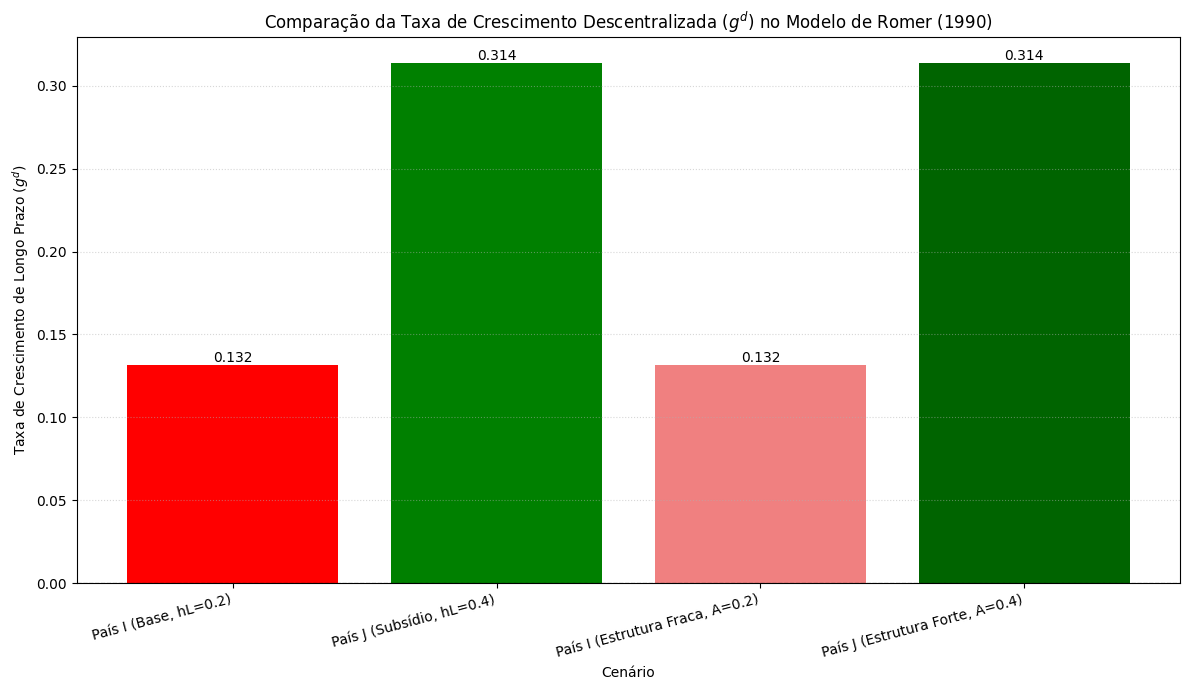

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------
# 1. Definição da Função de Crescimento Descentralizada (g^d)
# ----------------------------------------------------

def g_decentralized(A, hL, alpha, rho):
    """
    Calcula a taxa de crescimento de longo prazo descentralizada (g^d) 
    no modelo de Romer (simplificado para fins de ilustração).
    
    A: Produtividade do setor de P&D (escala).
    hL: Proporção de capital humano alocada para P&D (L_A/L).
    alpha: Parcela de capital intermediário na produção (relacionado ao mark-up).
    rho: Taxa de preferência temporal (desconto).
    """
    # A forma usada é uma representação da relação g = f(A*hL) - rho
    # O termo (1/alpha) amplifica o impacto de A*hL, sendo relacionado ao mark-up de monopólio.
    return (A * hL * (1/alpha) - rho) 

# ----------------------------------------------------
# 2. Definição dos Parâmetros e Cenários
# ----------------------------------------------------

# Parâmetros Fixos
alpha = 0.33  # 1/3
rho = 0.05    # 5%

# CASO 1: Incentivo Governamental Direto (Varia hL)
# J subsidia P&D -> aumenta hL
A_base = 0.3          # Produtividade da P&D (A) é a mesma.
hL_I_base = 0.2       # País I: Baixa alocação (sem subsídio).
hL_J_subsidy = 0.4    # País J: Alta alocação (com subsídio).

g_I_base = g_decentralized(A_base, hL_I_base, alpha, rho)
g_J_subsidy = g_decentralized(A_base, hL_J_subsidy, alpha, rho)

# CASO 2: Diferença Estrutural/Escala (Varia A)
# J tem maior escala/produtividade estrutural (A maior).
hL_estrutural = 0.3   # Alocação de trabalho (hL) é similar.
A_I_low = 0.2         # País I: Baixa produtividade/escala em P&D.
A_J_high = 0.4        # País J: Alta produtividade/escala em P&D.

g_I_low_A = g_decentralized(A_I_low, hL_estrutural, alpha, rho)
g_J_high_A = g_decentralized(A_J_high, hL_estrutural, alpha, rho)

# ----------------------------------------------------
# 3. Visualização dos Resultados (Gráfico de Barras)
# ----------------------------------------------------

# O restante do código gera o gráfico de barras comparando os 4 resultados
# ... (código para plotagem)
# Dados para o Gráfico
growth_rates = [g_I_base, g_J_subsidy, g_I_low_A, g_J_high_A]
labels = [
    'País I (Base, hL=0.2)', 
    'País J (Subsídio, hL=0.4)', 
    'País I (Estrutura Fraca, A=0.2)', 
    'País J (Estrutura Forte, A=0.4)'
]
colors = ['red', 'green', 'lightcoral', 'darkgreen']
x = np.arange(len(labels))

plt.figure(figsize=(12, 7))
bars = plt.bar(x, growth_rates, color=colors)

# Adicionar a linha de crescimento zero
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)

# Adicionar o valor de g em cada barra (opcional, mas útil para didática)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.3f}', ha='center', va='bottom' if yval > 0 else 'top')

plt.title('Comparação da Taxa de Crescimento Descentralizada ($g^d$) no Modelo de Romer (1990)')
plt.xlabel('Cenário')
plt.ylabel('Taxa de Crescimento de Longo Prazo ($g^d$)')
plt.xticks(x, labels, rotation=15, ha='right')
plt.grid(axis='y', linestyle='dotted', alpha=0.5)

plt.tight_layout()
plt.show() # ESTA É A LINHA CRUCIAL PARA EXIBIR A JANELA DO GRÁFICO!

Exercício 3 - Efeitos das externalidades  
  
A partir do código base, explore:  
  
1) Altere o parâmetro de alocação de capital humano (0.3; 0.5; e 0.7)
2) Altere os parâmetros de escala de produtividade (0.3; 0.5; e 0.7)   
3) Altere os parâmetros do mark-up (0.3; 0.5; e 0.7)
4) Altere a taxa de desconto (0.02; 0.05; e 0.10)
5) Qual o resultado para uma economia com baixa alocação para capital humano (0.3), alta escala de produtividade (0.8) e mark-up alto (0.7)?
6) Qual o resultado para uma economia com média alocação para capital humano (0.5), alta escala de produtividade (0.8) e mark-up baixo (0.3)?
7) Manipule os parâmetros (cidados acima e outros do código) para se aproximar das características de uma economia similar ao Brasil
8) Faça o mesmo para estimar uma economia hipotética para os EUA e China
9) Compare os três países (Brasil, EUA e China)  
  
Obs. use como padrão os spillovers de conhecimento fortes como em Romer (1990)

<>:73: SyntaxWarning: invalid escape sequence '\p'
<>:74: SyntaxWarning: invalid escape sequence '\p'
<>:73: SyntaxWarning: invalid escape sequence '\p'
<>:74: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_67683/2430695417.py:73: SyntaxWarning: invalid escape sequence '\p'
  plt.title('Impacto da Força do Spillover de Conhecimento ($\phi$) no Crescimento Endógeno')
/tmp/ipykernel_67683/2430695417.py:74: SyntaxWarning: invalid escape sequence '\p'
  plt.xlabel('Força do Spillover de Conhecimento ($\phi$)')


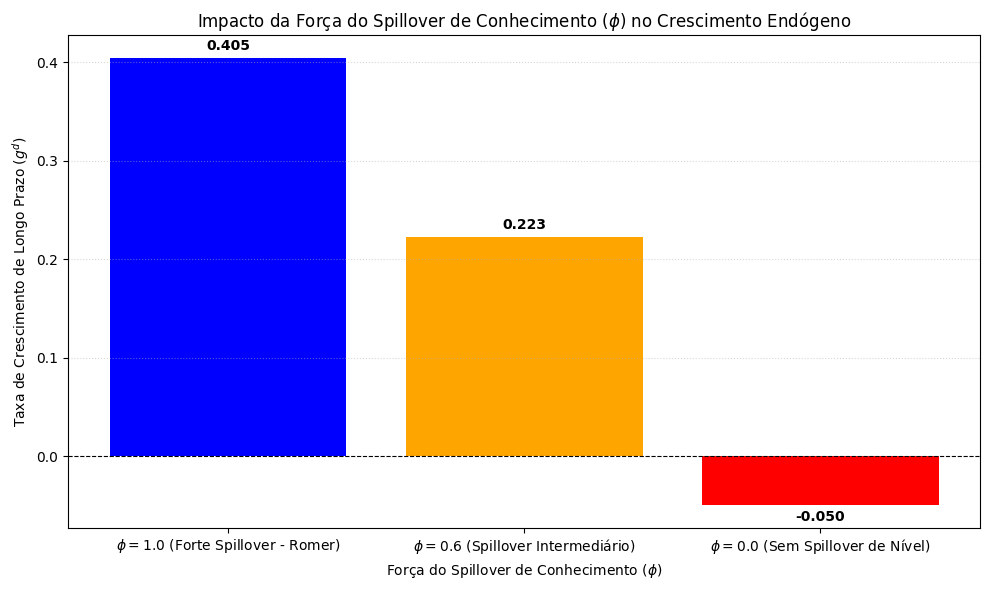

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------
# 1. Definição da Função de Crescimento Descentralizada (g^d)
# ----------------------------------------------------

def g_decentralized_phi(A_base, phi, hL, alpha, rho):
    """
    Calcula a taxa de crescimento de longo prazo descentralizada (g^d),
    introduzindo 'phi' como um indicador da força do spillover de conhecimento
    na determinação da taxa de crescimento.
    
    A_base: Produtividade de P&D (delta).
    phi: Indicador da força do Spillover de Conhecimento (expoente no estoque A, simplificado).
    hL: Proporção de capital humano alocada para P&D (L_A/L).
    alpha: Parcela de capital intermediário na produção (relacionado ao mark-up).
    rho: Taxa de preferência temporal (desconto).
    """
    # A inclusão de phi é feita multiplicando A_base por phi, refletindo
    # como a força do spillover afeta a produtividade efetiva da P&D.
    return (A_base * phi * hL * (1/alpha) - rho)

# ----------------------------------------------------
# 2. Definição dos Parâmetros e Cenários
# ----------------------------------------------------

# Parâmetros Fixos Comuns
alpha = 0.33  # 1/3 (Mark-up)
rho = 0.05    # 5% (Taxa de desconto)

# Parâmetros fixados para a P&D
A_base = 0.5  # Produtividade/escala de P&D
hL = 0.3      # Alocação de capital humano para P&D (30%)

# Cenários de Spillover de Conhecimento (phi)
phi_scenarios = {
    r'$\phi=1.0$ (Forte Spillover - Romer)': 1.0,
    r'$\phi=0.6$ (Spillover Intermediário)': 0.6,
    r'$\phi=0.0$ (Sem Spillover de Nível)': 0.0
}

# ----------------------------------------------------
# 3. Cálculo das Taxas de Crescimento
# ----------------------------------------------------

growth_rates_phi = {}
for label, phi_val in phi_scenarios.items():
    g_rate = g_decentralized_phi(A_base, phi_val, hL, alpha, rho)
    growth_rates_phi[label] = g_rate

# ----------------------------------------------------
# 4. Visualização dos Resultados
# ----------------------------------------------------

labels = list(growth_rates_phi.keys())
g_values = list(growth_rates_phi.values())
x = np.arange(len(labels))
colors = ['blue', 'orange', 'red']

plt.figure(figsize=(10, 6))
bars = plt.bar(x, g_values, color=colors)

# Adicionar a linha de crescimento zero
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)

# Adicionar o valor de g em cada barra
for bar in bars:
    yval = bar.get_height()
    va = 'bottom' if yval > 0 else 'top'
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + np.sign(yval) * 0.005, f'{yval:.3f}', ha='center', va=va, fontweight='bold')

plt.title('Impacto da Força do Spillover de Conhecimento ($\phi$) no Crescimento Endógeno')
plt.xlabel('Força do Spillover de Conhecimento ($\phi$)')
plt.ylabel('Taxa de Crescimento de Longo Prazo ($g^d$)')
plt.xticks(x, labels)
plt.grid(axis='y', linestyle='dotted', alpha=0.5)

plt.tight_layout()
plt.show()